# Car Price Prediction using Machine Learning
## Oasis Infobyte Data Science Internship - Task 2
**Name:** Srajan Shukla
## Objective

The objective of this project is to build a machine learning regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, transmission, and other vehicle characteristics.

## Import Required Libraries

In this step, we import the libraries required for data analysis, visualization, preprocessing, and machine learning.

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [34]:
car= pd.read_csv("cardekho.csv")
print(car.head())

                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner  mileage(km/ltr/kg)  engine  \
0  Individual       Manual   First Owner               23.40  1248.0   
1  Individual       Manual  Second Owner               21.14  1498.0   
2  Individual       Manual   Third Owner               17.70  1497.0   
3  Individual       Manual   First Owner               23.00  1396.0   
4  Individual       Manual   First Owner               16.10  1298.0   

  max_power  seats  
0        74    5.0  
1    103.52    5.0  
2        78    5.0  
3        90    5.0  
4      88.2

## Explore the Dataset

Inspect the dataset to understand its structure, columns, data types, and identify missing values before cleaning.

In [35]:
car.shape

(8128, 12)

In [36]:
car.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power',
       'seats'],
      dtype='str')

In [37]:
car.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   str    
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   str    
 5   seller_type         8128 non-null   str    
 6   transmission        8128 non-null   str    
 7   owner               8128 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   str    
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 762.1 KB


In [38]:
car.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [39]:
car.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [40]:
duplicate_cars= car.duplicated()
duplicate_cars.sum()

np.int64(1202)

In [41]:
car = car.drop_duplicates()

In [42]:
car.duplicated().sum()

np.int64(0)

## Step 5: Feature Engineering

Feature engineering is the process of creating new features from existing data to improve the performance of a machine learning model.

In [43]:
car["Car_Age"] = pd.Timestamp.now().year - car["year"]
print(car)

                                   name  year  selling_price  km_driven  \
0                Maruti Swift Dzire VDI  2014         450000     145500   
1          Skoda Rapid 1.5 TDI Ambition  2014         370000     120000   
2              Honda City 2017-2020 EXi  2006         158000     140000   
3             Hyundai i20 Sportz Diesel  2010         225000     127000   
4                Maruti Swift VXI BSIII  2007         130000     120000   
...                                 ...   ...            ...        ...   
8121  Maruti Wagon R VXI BS IV with ABS  2013         260000      50000   
8122         Hyundai i20 Magna 1.4 CRDi  2014         475000      80000   
8123                  Hyundai i20 Magna  2013         320000     110000   
8124              Hyundai Verna CRDi SX  2007         135000     119000   
8125             Maruti Swift Dzire ZDi  2009         382000     120000   

        fuel seller_type transmission                 owner  \
0     Diesel  Individual       Manua

In [44]:
car["name"].head(10)

0                  Maruti Swift Dzire VDI
1            Skoda Rapid 1.5 TDI Ambition
2                Honda City 2017-2020 EXi
3               Hyundai i20 Sportz Diesel
4                  Maruti Swift VXI BSIII
5           Hyundai Xcent 1.2 VTVT E Plus
6            Maruti Wagon R LXI DUO BSIII
7                      Maruti 800 DX BSII
8                        Toyota Etios VXD
9    Ford Figo Diesel Celebration Edition
Name: name, dtype: str

In [45]:
car["brand"] = car["name"].str.split().str[0]

In [46]:
car[["name", "brand"]].head()

,name,brand
0,Maruti Swift Dzire VDI,Maruti
1,Skoda Rapid 1.5 TDI Ambition,Skoda
2,Honda City 2017-2020 EXi,Honda
3,Hyundai i20 Sportz Diesel,Hyundai
4,Maruti Swift VXI BSIII,Maruti


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the data through visualizations and identify patterns, trends, and relationships between variables.

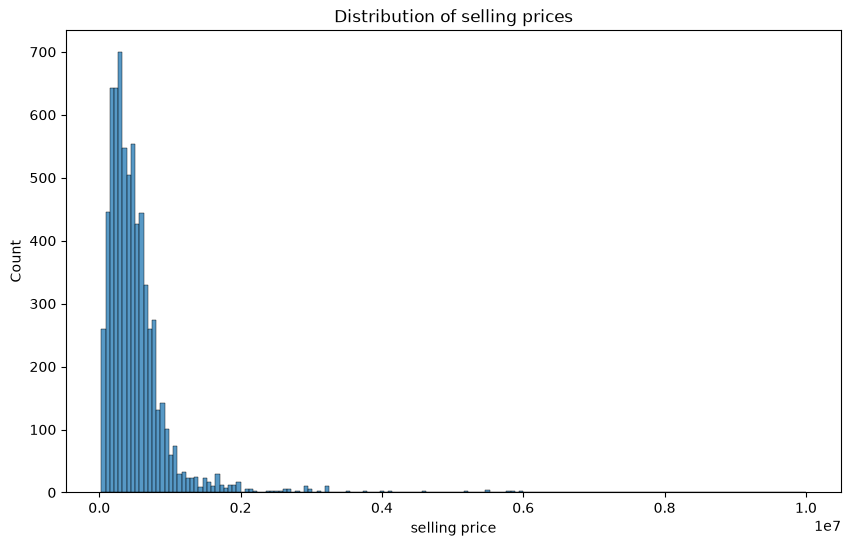

In [47]:
plt.figure(figsize=(10,6))
sns.histplot(data=car,x="selling_price")
plt.xlabel("selling price")
plt.ylabel("Count")
plt.title("Distribution of selling prices")
plt.show()

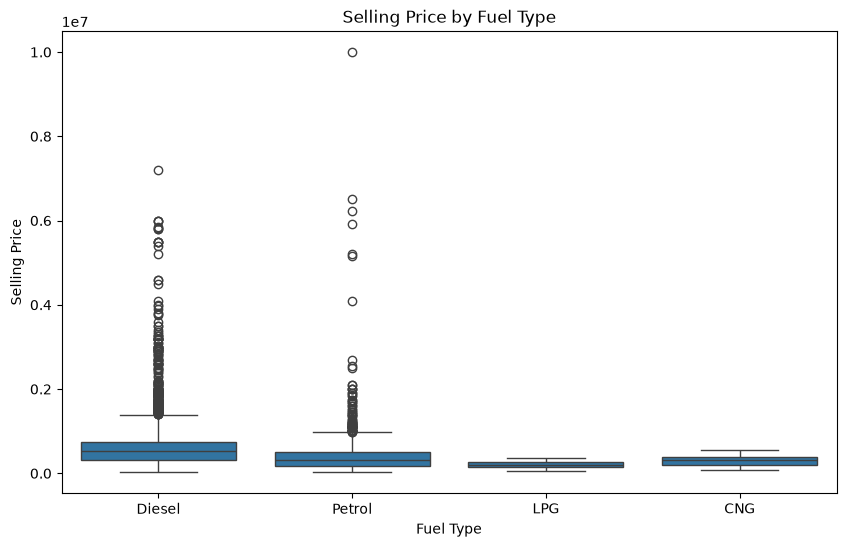

In [48]:
plt.figure(figsize=(10,6))
sns.boxplot(data=car,x="fuel",y="selling_price")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.title("Selling Price by Fuel Type")
plt.show()

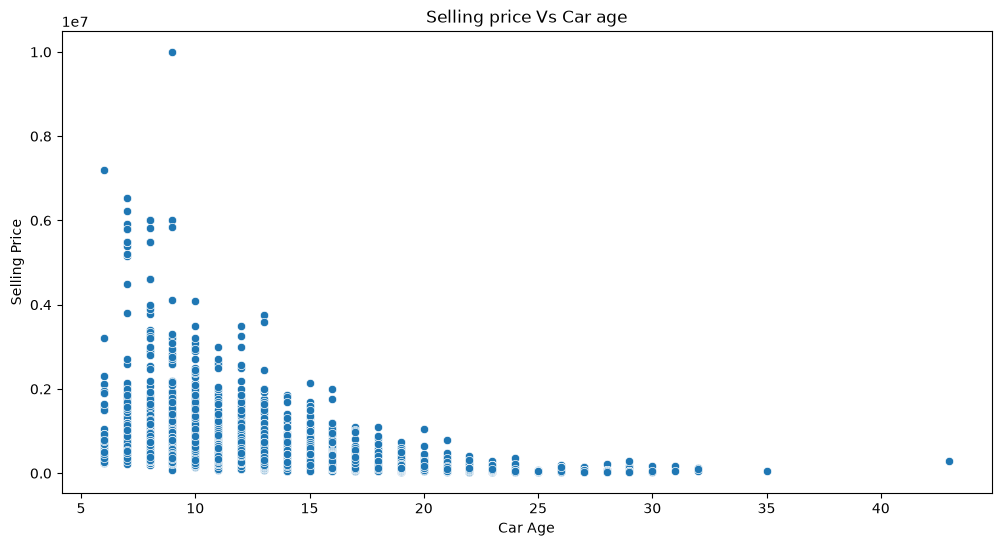

In [49]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=car,x="Car_Age",y="selling_price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.title("Selling price Vs Car age")
plt.show()

In [50]:
numeric_car = car.select_dtypes(include="number")

In [51]:
numeric_car.corr()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats,Car_Age
year,1.000000,0.433076,-0.377003,0.366694,-0.019074,0.023632,-1.000000
selling_price,0.433076,1.000000,-0.165620,-0.108344,0.442857,0.158111,-0.433076
km_driven,-0.377003,-0.165620,1.000000,-0.196494,0.253339,0.207957,0.377003
mileage(km/ltr/kg),0.366694,-0.108344,-0.196494,1.000000,-0.578483,-0.459624,-0.366694
engine,-0.019074,0.442857,0.253339,-0.578483,1.000000,0.657798,0.019074
seats,0.023632,0.158111,0.207957,-0.459624,0.657798,1.000000,-0.023632
Car_Age,-1.000000,-0.433076,0.377003,-0.366694,0.019074,-0.023632,1.000000


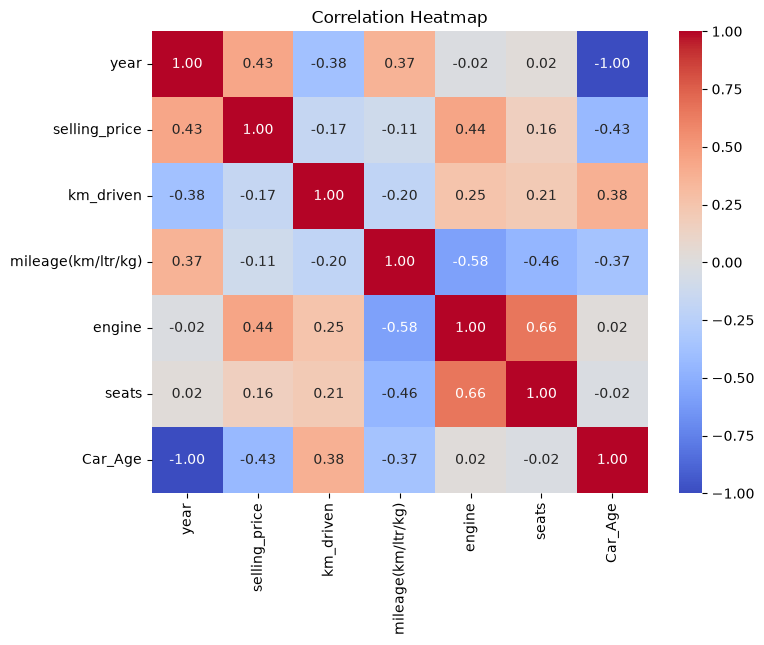

In [52]:
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_car.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Encoding Categorical Variables

Machine learning models cannot understand text values directly. Therefore, categorical variables are converted into numerical values using One-Hot Encoding.

In [53]:
car_encoded = pd.get_dummies(car,columns=["fuel", "seller_type", "transmission",
                                          "owner", "brand"],drop_first=True)

car_encoded.head()

,name,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats,Car_Age,fuel_Diesel,...,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Peugeot,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,Maruti Swift Dzire VDI,2014,450000,145500,23.40,1248.0,74,5.0,12,True,...,False,False,False,False,False,False,False,False,False,False
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,21.14,1498.0,103.52,5.0,12,True,...,False,False,False,False,False,True,False,False,False,False
2,Honda City 2017-2020 EXi,2006,158000,140000,17.70,1497.0,78,5.0,20,False,...,False,False,False,False,False,False,False,False,False,False
3,Hyundai i20 Sportz Diesel,2010,225000,127000,23.00,1396.0,90,5.0,16,True,...,False,False,False,False,False,False,False,False,False,False
4,Maruti Swift VXI BSIII,2007,130000,120000,16.10,1298.0,88.2,5.0,19,False,...,False,False,False,False,False,False,False,False,False,False


## Feature Selection

The dataset is divided into independent variables (X) and the target variable (y).

In [54]:
X = car_encoded.drop(columns=["selling_price", "name"])
y = car_encoded["selling_price"]

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [56]:
from sklearn.linear_model import LinearRegression

In [58]:
X_train.dtypes

year                              int64
km_driven                         int64
mileage(km/ltr/kg)              float64
engine                          float64
max_power                           str
seats                           float64
Car_Age                           int64
fuel_Diesel                        bool
fuel_LPG                           bool
fuel_Petrol                        bool
seller_type_Individual             bool
seller_type_Trustmark Dealer       bool
transmission_Manual                bool
owner_Fourth & Above Owner         bool
owner_Second Owner                 bool
owner_Test Drive Car               bool
owner_Third Owner                  bool
brand_Ashok                        bool
brand_Audi                         bool
brand_BMW                          bool
brand_Chevrolet                    bool
brand_Daewoo                       bool
brand_Datsun                       bool
brand_Fiat                         bool
brand_Force                        bool
